In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import os
import re
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import time

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [3]:
eng_alphabets = 'abcdefghijklmnopqrstuvwxyz'
pad_char = '-PAD-'

eng_alpha2index = {pad_char: 0}
for index, alpha in enumerate(eng_alphabets):
    eng_alpha2index[alpha] = index + 1

rus_alphabets = 'абвгдежзийклмнопрстуфхцчшщъыьэюя'

# Create a mapping for Russian characters
rus_alpha2index = {pad_char: 0}
for index, alpha in enumerate(rus_alphabets):
    rus_alpha2index[alpha] = index + 1

In [4]:
non_eng_letters_regex = re.compile('[^a-zA-Z ]')
non_rus_letters_regex = re.compile('[^а-яА-ЯёЁ ]')

def cleanEnglishVocab(line):
    line = line.replace('-', ' ').replace(',', ' ').strip()
    line = non_eng_letters_regex.sub('', line)
    return line.split()

def cleanRussianVocab(line):
    line = line.replace('-', ' ').replace(',', ' ').strip()
    line = non_rus_letters_regex.sub('', line)
    return line.split()

In [5]:
def load_data_from_json(json_file):
    import json
    with open(json_file, 'r') as f:
        data = json.load(f)
        data = data.get("LANG_RUS", [])
        return data

In [8]:
data = load_data_from_json('cleaned_dataset.json')

In [9]:
class TransliterationDataLoader(Dataset):
    def __init__(self, data):
        self.eng_words, self.rus_words = self.readJsonDataset(data)
        self.shuffle_indices = list(range(len(self.eng_words)))
        random.shuffle(self.shuffle_indices)
        self.shuffle_start_index = 0
        
    def __len__(self):
        return len(self.eng_words)
    
    def __getitem__(self, idx):
        return self.eng_words[idx], self.rus_words[idx]
    
    @staticmethod
    def split_data(data, test_size=1000):
        random.shuffle(data)
        test_size = min(test_size, len(data))
        train_data = data[:-test_size]
        test_data = data[-test_size:]
        return train_data, test_data
    
    def readJsonDataset(self, data):
        lang1_words = []
        lang2_words = []

        for entry in data:
            wordlist1 = cleanEnglishVocab(entry['input'])
            wordlist2 = cleanRussianVocab(entry['output'])

            if len(wordlist1) != len(wordlist2):
                print('Skipping: ', entry['input'], ' - ', entry['output'])
                continue

            lang1_words.extend(wordlist1)
            lang2_words.extend(wordlist2)

        return lang1_words, lang2_words
    
    def get_random_sample(self):
        index = random.randint(0, len(self.eng_words) - 1)
        return self.eng_words[index], self.rus_words[index]
    
    def get_batch_from_array(self, batch_size, array):
        end = self.shuffle_start_index + batch_size
        batch = []
        if end >= len(self.eng_words):
            batch = [array[i] for i in self.shuffle_indices[0:end % len(self.eng_words)]]
            end = len(self.eng_words)
        return batch + [array[i] for i in self.shuffle_indices[self.shuffle_start_index: end]]
    
    def get_batch(self, batch_size, postprocess=True):
        eng_batch = self.get_batch_from_array(batch_size, self.eng_words)
        rus_batch = self.get_batch_from_array(batch_size, self.rus_words)
        self.shuffle_start_index += batch_size + 1
        
        if self.shuffle_start_index >= len(self.eng_words):
            random.shuffle(self.shuffle_indices)
            self.shuffle_start_index = 0
            
        return eng_batch, rus_batch

In [10]:
train_data, test_data = TransliterationDataLoader.split_data(data, test_size=1000)

train_data = TransliterationDataLoader(train_data)
test_data = TransliterationDataLoader(test_data)


In [11]:
def word_rep(word, letter2index, device=device):
    rep = torch.zeros(len(word) + 1, 1, len(letter2index)).to(device)
    for letter_index, letter in enumerate(word):
        pos = letter2index[letter]
        rep[letter_index][0][pos] = 1
    pad_pos = letter2index[pad_char]
    rep[letter_index + 1][0][pad_pos] = 1
    return rep

def gt_rep(word, letter2index, device=device):
    gt_rep = torch.zeros([len(word) + 1, 1], dtype=torch.long).to(device)
    for letter_index, letter in enumerate(word):
        pos = letter2index[letter]
        gt_rep[letter_index][0] = pos
    gt_rep[letter_index + 1][0] = letter2index[pad_char]
    return gt_rep


In [12]:
class Transliteration_EncoderDecoder_Attention(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, verbose=False):
        super(Transliteration_EncoderDecoder_Attention, self).__init__()
        
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        # Replace GRU with LSTM
        self.encoder_rnn_cell = nn.LSTM(input_size, hidden_size)
        self.decoder_rnn_cell = nn.LSTM(hidden_size * 2, hidden_size)
        
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=2)
        
        self.U = nn.Linear(self.hidden_size, self.hidden_size)
        self.W = nn.Linear(self.hidden_size, self.hidden_size)
        self.attn = nn.Linear(self.hidden_size, 1)
        self.out2hidden = nn.Linear(self.output_size, self.hidden_size)   
        
        self.verbose = verbose
        
    def forward(self, input, max_output_chars=20, device=device, ground_truth=None):
        # Encoder LSTM
        encoder_outputs, (hidden, cell) = self.encoder_rnn_cell(input)
        encoder_outputs = encoder_outputs.view(-1, self.hidden_size)
        
        if self.verbose:
            print('Encoder output', encoder_outputs.shape)
        
        # Decoder LSTM
        decoder_state = (hidden, cell)  # LSTM uses both hidden and cell states
        decoder_input = torch.zeros(1, 1, self.output_size).to(device)
        
        outputs = []
        U = self.U(encoder_outputs)
        
        if self.verbose:
            print('Decoder state (hidden)', hidden.shape)
            print('Decoder state (cell)', cell.shape)
            print('Decoder intermediate input', decoder_input.shape)
            print('U * Encoder output', U.shape)
        
        for i in range(max_output_chars):
            # Attention mechanism
            W = self.W(hidden.view(1, -1).repeat(encoder_outputs.shape[0], 1))
            V = self.attn(torch.tanh(U + W))
            attn_weights = F.softmax(V.view(1, -1), dim=1)
            
            if self.verbose:
                print('W * Decoder state', W.shape)
                print('V', V.shape)
                print('Attn', attn_weights.shape)
            
            attn_applied = torch.bmm(attn_weights.unsqueeze(0), encoder_outputs.unsqueeze(0))
            
            embedding = self.out2hidden(decoder_input)
            decoder_input = torch.cat((embedding[0], attn_applied[0]), 1).unsqueeze(0)
            
            if self.verbose:
                print('Attn LC', attn_applied.shape)
                print('Decoder input', decoder_input.shape)
                
            # Decoder LSTM step
            out, (hidden, cell) = self.decoder_rnn_cell(decoder_input, decoder_state)
            
            if self.verbose:
                print('Decoder intermediate output', out.shape)
                
            # Output layer
            out = self.h2o(hidden)  # Use hidden state for output
            out = self.softmax(out)
            outputs.append(out.view(1, -1))
            
            if self.verbose:
                print('Decoder output', out.shape)
                self.verbose = False
            
            # Teacher forcing or greedy decoding
            max_idx = torch.argmax(out, 2, keepdim=True)
            if not ground_truth is None:
                max_idx = ground_truth[i].reshape(1, 1, 1)
            one_hot = torch.zeros(out.shape, device=device)
            one_hot.scatter_(2, max_idx, 1) 
            
            decoder_input = one_hot.detach()
            
        return outputs

In [13]:
def infer(model, eng_word, shape, device=device):
    model.eval()
    input_ = word_rep(eng_word, eng_alpha2index, device)
    outputs = model(input_, shape, device)
    
    return outputs


In [14]:
model_attention = Transliteration_EncoderDecoder_Attention(len(eng_alpha2index), 256, len(rus_alpha2index), verbose=True)
model_attention.to(device)

/opt/Programming/Python/AI/Transliteration/AI/lib/python3.12/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Transliteration_EncoderDecoder_Attention(
  (encoder_rnn_cell): LSTM(27, 256)
  (decoder_rnn_cell): LSTM(512, 256)
  (h2o): Linear(in_features=256, out_features=33, bias=True)
  (softmax): LogSoftmax(dim=2)
  (U): Linear(in_features=256, out_features=256, bias=True)
  (W): Linear(in_features=256, out_features=256, bias=True)
  (attn): Linear(in_features=256, out_features=1, bias=True)
  (out2hidden): Linear(in_features=33, out_features=256, bias=True)
)

In [15]:
def train_batch(model, opt, criterion, batch_size, device=device, teacher_force=False):
    model.train().to(device)
    opt.zero_grad()
    eng_batch, rus_batch = train_data.get_batch(batch_size)
    
    total_loss = 0
    for i in range(batch_size):
        input = word_rep(eng_batch[i], eng_alpha2index, device)
        gt = gt_rep(rus_batch[i], rus_alpha2index, device)
        outputs = model(input, gt.shape[0], device, ground_truth=gt if teacher_force else None)
        
        for index, output in enumerate(outputs):
            loss = criterion(output, gt[index]) / batch_size
            loss.backward(retain_graph=True)
            total_loss += loss
        
    opt.step()
    
    return total_loss / batch_size

In [16]:
def train_setup(model, lr=0.01, n_batches=100, batch_size=10, momentum=0.9, display_freq=5, device=device):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    opt = optim.Adam(model.parameters(), lr=lr)
    teacher_force_upto = n_batches // 3
    
    loss_arr = np.zeros(n_batches + 1)
    
    start_time = time.time()  # Start the timer
    last_batch_time = start_time  # Initialize last batch time

    for i in range(n_batches):
        # Train the batch and calculate loss
        loss_arr[i + 1] = (loss_arr[i] * i + train_batch(model, opt, criterion, batch_size, device=device, teacher_force=i < teacher_force_upto)) / (i + 1)
        
        if i % 50 == 0:
            save_path = './model_V8.2_savepoints_2000-4000'
            os.makedirs(save_path, exist_ok=True)
            model_save_path = os.path.join(save_path, f'model_batch_{2000+i}.pt')
            torch.save(model.state_dict(), model_save_path)
            print(f"Model saved at: {model_save_path}")
        
        # Calculate elapsed time
        elapsed_time = time.time() - start_time
        
        # Calculate time taken for the last batch
        current_batch_time = time.time()
        time_for_last_batch = current_batch_time - last_batch_time
        last_batch_time = current_batch_time  # Update last batch time
        
        # Predict remaining time
        predicted_time = time_for_last_batch * (n_batches - (i + 1))
        
        # Print elapsed and predicted time
        print(f"Batch {i + 1}/{n_batches}, Elapsed time: {elapsed_time:.2f} seconds, Predicted time remaining: {predicted_time:.2f} seconds")
        
        print(i)


In [17]:
loss_history = train_setup(model_attention, lr=0.001, n_batches=2001, batch_size=32, display_freq=1, device=device)

Model saved at: ./model_V8.2_savepoints_2000-4000/model_batch_2000.pt
Batch 1/2001, Elapsed time: 1.87 seconds, Predicted time remaining: 3733.38 seconds
0
Batch 2/2001, Elapsed time: 3.25 seconds, Predicted time remaining: 2774.42 seconds
1
Batch 3/2001, Elapsed time: 4.57 seconds, Predicted time remaining: 2623.04 seconds
2
Batch 4/2001, Elapsed time: 5.71 seconds, Predicted time remaining: 2276.07 seconds
3
Batch 5/2001, Elapsed time: 7.14 seconds, Predicted time remaining: 2860.00 seconds
4
Batch 6/2001, Elapsed time: 8.73 seconds, Predicted time remaining: 3173.65 seconds
5
Batch 7/2001, Elapsed time: 10.14 seconds, Predicted time remaining: 2815.36 seconds
6
Batch 8/2001, Elapsed time: 11.43 seconds, Predicted time remaining: 2563.26 seconds
7
Batch 9/2001, Elapsed time: 12.81 seconds, Predicted time remaining: 2754.66 seconds
8
Batch 10/2001, Elapsed time: 14.41 seconds, Predicted time remaining: 3188.55 seconds
9
Batch 11/2001, Elapsed time: 15.55 seconds, Predicted time remain

In [21]:
def load_model(model_path):
    model = Transliteration_EncoderDecoder_Attention(len(eng_alpha2index), 256, len(rus_alpha2index))
    model.load_state_dict(torch.load(model_path, map_location=device))
    return model

model_attention = load_model('/opt/Programming/Python/AI/Transliteration/model_V8.2/model_V8.2_savepoints_2000-4000/model_batch_4000.pt')

In [19]:
def test(model, word, device=device):
    model = model.eval().to(device)
    outputs = infer(model, word, 30, device)
    rus_output = ''
    for out in outputs:
        val, indices = out.topk(1)
        index = indices.tolist()[0][0]
        if index == 0:
            break
        rus_char = rus_alphabets[index - 1]  # Adjusted index for correct mapping
        rus_output += rus_char
    print(word + ' - ' + rus_output)
    return rus_output

In [20]:
def calc_accuracy(model, device=device):
    model = model.eval().to(device)
    predictions = []
    accuracy = 0
    for i in range(len(test_data)):
        eng, rus = test_data[i]
        gt = gt_rep(rus, rus_alpha2index, device)
        outputs = infer(model, eng, gt.shape[0], device)
        correct = 0
        for index, out in enumerate(outputs):
            val, indices = out.topk(1)
            rus_pos = indices.tolist()[0]
            if rus_pos[0] == gt[index][0]:
                correct += 1
        
        accuracy += correct / gt.shape[0]
    accuracy /= len(test_data)
    return accuracy

In [22]:
def load_model(model_path):
    model = Transliteration_EncoderDecoder_Attention(len(eng_alpha2index), 256, len(rus_alpha2index))
    model.load_state_dict(torch.load(model_path, map_location=device))
    return model

# List to store results
model_names = []
accuracies = []

# Directory containing your models
model_directory = './model_V8.2_savepoints_2000-4000'

In [23]:
def extract_batch_number(filename):
    match = re.search(r'_(\d+)\.pt$', filename)
    return int(match.group(1)) if match else float('inf')
files = os.listdir(model_directory)
sorted_files = sorted(files, key=extract_batch_number)

print(sorted_files)


['model_batch_2000.pt', 'model_batch_2050.pt', 'model_batch_2100.pt', 'model_batch_2150.pt', 'model_batch_2200.pt', 'model_batch_2250.pt', 'model_batch_2300.pt', 'model_batch_2350.pt', 'model_batch_2400.pt', 'model_batch_2450.pt', 'model_batch_2500.pt', 'model_batch_2550.pt', 'model_batch_2600.pt', 'model_batch_2650.pt', 'model_batch_2700.pt', 'model_batch_2750.pt', 'model_batch_2800.pt', 'model_batch_2850.pt', 'model_batch_2900.pt', 'model_batch_2950.pt', 'model_batch_3000.pt', 'model_batch_3050.pt', 'model_batch_3100.pt', 'model_batch_3150.pt', 'model_batch_3200.pt', 'model_batch_3250.pt', 'model_batch_3300.pt', 'model_batch_3350.pt', 'model_batch_3400.pt', 'model_batch_3450.pt', 'model_batch_3500.pt', 'model_batch_3550.pt', 'model_batch_3600.pt', 'model_batch_3650.pt', 'model_batch_3700.pt', 'model_batch_3750.pt', 'model_batch_3800.pt', 'model_batch_3850.pt', 'model_batch_3900.pt', 'model_batch_3950.pt', 'model_batch_4000.pt']


In [24]:
for model_file in sorted_files:
    if model_file.endswith('.pt'):
        model_path = os.path.join(model_directory, model_file)
        model = load_model(model_path).to(device)  # Load and move model to device
        
        # Run the test function on a sample word
        sample_word = "example"  # Replace with your actual test words
        test(model, sample_word, device)
        
        # Calculate accuracy
        accuracy = calc_accuracy(model, device)
        
        # Store results
        model_names.append(model_file)
        accuracies.append(accuracy)

example - экэмпэплл
example - экэмпли
example - эксмпл
example - иксмпл
example - иксмпл
example - иксэпэл
example - иксэпл
example - экэмпэл
example - иксмпл
example - иксмпэл
example - иксмпэл
example - иксмпл
example - икэмпэлэл
example - иксэмпл
example - иксэмпл
example - иксмпэл
example - икэмэмплл
example - иксмпэпл
example - икэмпл
example - иксмпэпэл
example - иксмпплл
example - иксэмпл
example - иксэпэл
example - иксмпэл
example - иксмпэл
example - иксэппл
example - эксмэплэ
example - иксмпэл
example - иксэмпэл
example - икэмэпэл
example - иксмэпэл
example - икзэппэл
example - иксмппэл
example - иксэмпэл
example - иксмэпээ
example - эксэмпэл
example - экэмпэлэ
example - иксмппл
example - иксмппэл
example - иксмппэл
example - иксмппэл


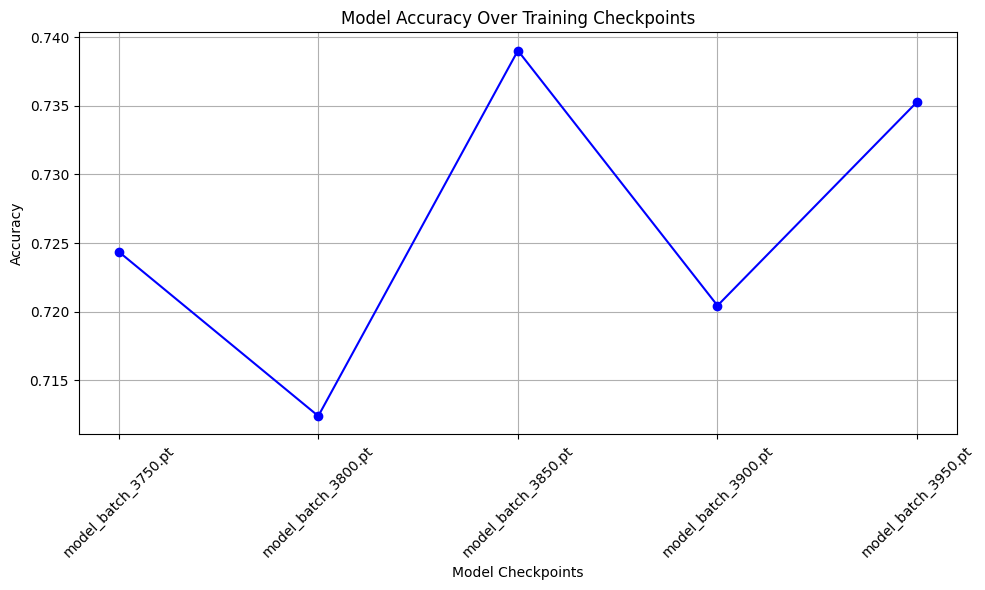

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(model_names[35:40], accuracies[35:40], marker='o', linestyle='-', color='b')
plt.xlabel('Model Checkpoints')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Over Training Checkpoints')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
# Use max with a key to get the index of the maximum accuracy
max_accuracy_index = max(range(len(accuracies)), key=accuracies.__getitem__)

# Get the maximum accuracy and corresponding model name
max_accuracy = accuracies[max_accuracy_index]
max_acc_model_name = model_names[max_accuracy_index]

print(f'Max Accuracy: {max_accuracy}, Model Name: {max_acc_model_name}')

Max Accuracy: 0.7390223512598522, Model Name: model_batch_3850.pt


In [22]:

# model_directory = './model_V8.2_savepoints_2000-4000'
# model_path = os.path.join(model_directory, max_acc_model_name)
# model = load_model(model_path).to(device)  # Load and move model to device
model = model_attention.to(device)
# Input a sentence to translate
input_sentence = "I am not sure the result is good enough. I also have no any idea why this one works so good!. Wild"  # Replace with your actual input sentence

# Use regex to find all words and non-word characters
words = re.findall(r'\b\w+\b', input_sentence)  # Extract words
non_words = re.findall(r'[^\w\s]+', input_sentence)  # Extract non-word characters

# Translate each word and combine the results
translated_words = []
for word in words:
    # Check if the word is uppercase
    is_upper = word.isupper()
    # Process the word in lowercase
    rus_output = test(model, word.lower(), device)  # Translate each word
    # Convert back to uppercase if the original word was uppercase
    if is_upper:
        rus_output = rus_output.upper()
    translated_words.append(rus_output)  # Collect the translated words

# Combine the translated words back into a single sentence
translated_sentence = ' '.join(translated_words) + ''.join(non_words)
print(f"Translated Sentence: {translated_sentence}")

i - и
am - эм
not - ннт
sure - сэр
the - фий
result - рэсэлт
is - из
good - гуд
enough - эноу
i - и
also - ллоу
have - хэв
no - н
any - эни
idea - айдэ
why - хвий
this - физ
one - оу
works - ворз
so - соу
good - гуд
wild - вилд
Translated Sentence: И эм ннт сэр фий рэсэлт из гуд эноу И ллоу хэв н эни айдэ хвий физ оу ворз соу гуд вилд.!.
